# **OU Schedule Generation (AFHQ)**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


## Imports

In [4]:
# %load_ext autoreload
# %autoreload 2

import torch

import sys, os
sys.path.append(os.path.abspath("./"))

import src.diffusion_process as dfp
from src.diffusion_utilities import plot_image_evolution, plot_image_grid
from src.ou_schedules import (
    make_ou_process_functions,
    make_reverse_drift_coefficient,
    make_ou_probability_flow_drift,
 )
from src.score_model import ScoreNet

## Basic configuration

In [5]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 1


## Configure schedule and load checkpoint

In [7]:
schedule_name = "cosine"
sched = make_ou_process_functions(schedule_name)

diffusion_coeff = sched["diffusion_coefficient"]
sigma_t = sched["sigma_t"]

# Define the score model
score_model = ScoreNet(
    marginal_prob_std=sigma_t,
    in_channels=3,
    out_channels=3,
    channels=(64, 128, 256, 512),
    embed_dim=256
).to(device)

# Load the model checkpoint
epoch = 2000
checkpoint_path = f"./checkpoints/afhq_ou_{schedule_name}/checkpoint_ou_{schedule_name}_epoch{epoch}_finetune.pth"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found at: {checkpoint_path}")

score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
score_model.eval()
print(f"Model loaded successfully from: {checkpoint_path}")

Model loaded successfully from: ./checkpoints/afhq_ou_cosine/checkpoint_ou_cosine_epoch2000_finetune.pth


## Define backward drift

In [8]:
backward_drift_coeff = make_reverse_drift_coefficient(sched, score_model)

## Generate images

In [9]:
n_eval_images = 20
batch_size = 32
T = 1.0
n_steps = 1000

final_images_pc_list = []

probability_flow_drift = make_ou_probability_flow_drift(sched, score_model)

score_model.eval()

t_vals = torch.tensor([1.0, 0.5, 0.1, 0.01, 0.001])
print("sigma_t:", sigma_t(t_vals))
print("beta_t: ", sched["beta_t"](t_vals))

with torch.no_grad():
    for start in range(0, n_eval_images, batch_size):
        current_batch = min(batch_size, n_eval_images - start)

        t_T = torch.ones(current_batch, device=device) * T

        image_T = torch.randn(
            current_batch, 3, 64, 64, device=device
        ) * sigma_t(t_T).view(-1, 1, 1, 1)

        _, synthetic_images_pc = dfp.predictor_corrector_sampler(
            image_T,
            t_0=T,
            t_end=1.0e-3,
            n_steps=n_steps,
            drift_coefficient=backward_drift_coeff,
            diffusion_coefficient=diffusion_coeff,
            score_model=score_model,
            n_corrector_steps=1,
            snr=0.03,
            seed=None,
        )

        final_images_pc_list.append(synthetic_images_pc[..., -1].detach().cpu())

final_images_pc = torch.cat(final_images_pc_list, dim=0)
print(final_images_pc.shape)

sigma_t: tensor([1.0000, 0.7114, 0.1671, 0.0251, 0.0064])
beta_t:  tensor([1.0000e-05, 3.1558e+00, 5.2954e-01, 8.7445e-02, 4.3714e-02])
torch.Size([20, 3, 64, 64])


## Visualize generation evolution

Predictor-Corrector


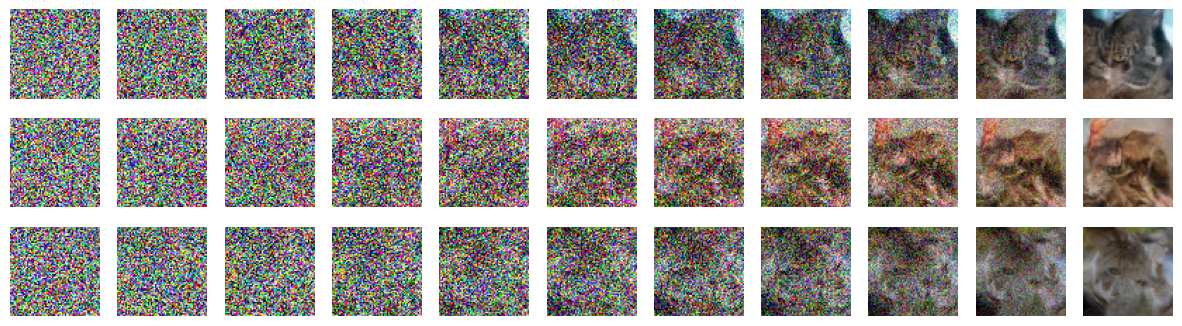

In [10]:
n_show = 3
indices = torch.randperm(synthetic_images_pc.shape[0])[:n_show]

print("Predictor-Corrector")
_ = plot_image_evolution(
    images=synthetic_images_pc[indices],
    n_images=n_show,
    n_intermediate_steps=[0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    figsize=(15, 4),
)

## Save images for measure

In [11]:
model_tag = f"afhq_ou_{schedule_name}"
save_dir = os.path.join("./samples", model_tag, f"epoch{epoch}")
os.makedirs(save_dir, exist_ok=True)

sample_file = os.path.join(save_dir, "final_images.pt")

torch.save(
    {
        "final_images_pc": final_images_pc.detach().cpu(),
    },
    sample_file,
)

print(f"Saved final samples to: {sample_file}")

Saved final samples to: ./samples/afhq_ou_cosine/epoch2000/final_images.pt


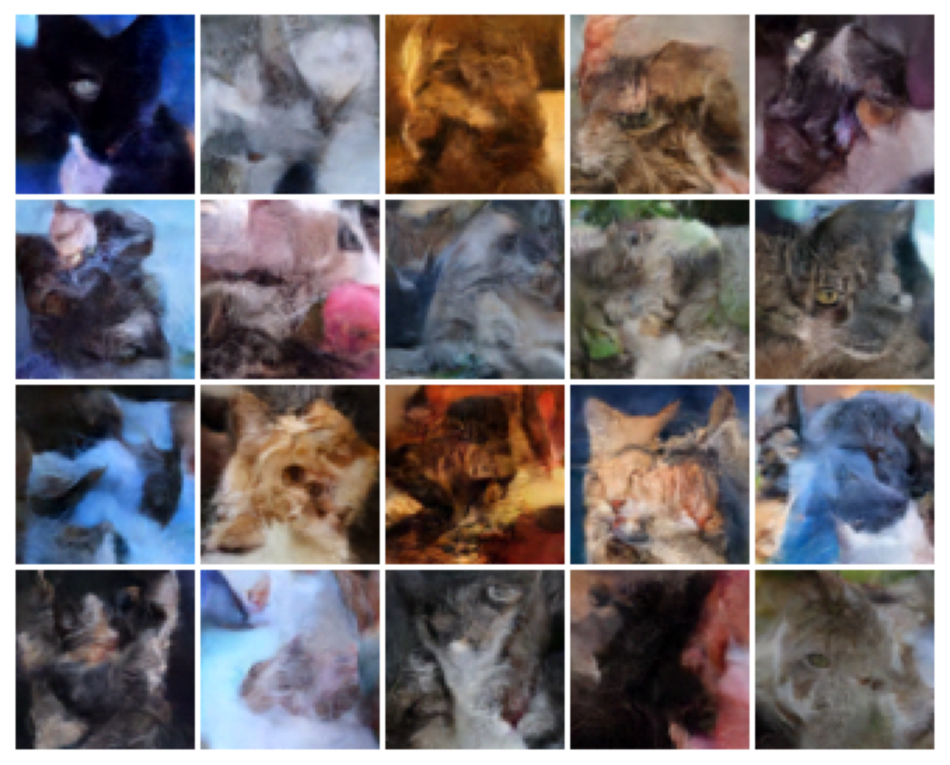

In [12]:
_ = plot_image_grid(
    images=final_images_pc[:20],
    figsize=(12, 12),
    n_rows=4,
    n_cols=5,
    cmap=None,
)